# Project : Rain Prediction in Australia using Deep Learning (ANN)
**Submitted By:**

FA23-BSCS-026 Sania Kiran

FA23-BSCS-032 Minahil Farooqi

**Course:** Machine Learning Fundamentals

**Resource Person:** Dr. Shazia Saqib

**Institution:** Institute for Arts and Culture

## Project Overview
We use the **Rain in Australia** dataset (from Kaggle / R rattle package) to predict whether it will rain tomorrow — a binary classification problem.

## Step 1: Install & Import Libraries

In [ ]:
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy -q
print("Done!")

Done!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported!")
print(f"TensorFlow: {tf.__version__}")

All libraries imported!
TensorFlow: 2.20.0


## Step 2: Load the Dataset
The dataset is hosted on GitHub (originally from Kaggle / R rattle package). No manual upload needed — we download it directly.

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'weatherAUS.csv')

print("Path to dataset files:", path)
print("Loading dataset...")
df = pd.read_csv(csv_file_path)
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}  ({df.shape[0]} rows x {df.shape[1]} columns)")
print(f"\nColumn names:")
print(list(df.columns))

Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.
Path to dataset files: /kaggle/input/weather-dataset-rattle-package
Loading dataset...
Dataset loaded successfully!
Shape: (145460, 23)  (145460 rows x 23 columns)

Column names:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


## Step 3: Explore the Dataset

In [ ]:
print("=" * 55)
print("FIRST 5 ROWS")
print("=" * 55)
df.head()

FIRST 5 ROWS


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
print(f"Rows         : {df.shape[0]}")
print(f"Columns      : {df.shape[1]}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic statistics for numeric columns:")
df.describe()

DATASET INFO
Rows         : 145460
Columns      : 23

Data types:
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

Basic statistics for numeric columns:


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [ ]:
print("=" * 55)
print("MISSING VALUES PER COLUMN")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print("\n=" * 3 + " TARGET VARIABLE DISTRIBUTION " + "=" * 3)
print(df['RainTomorrow'].value_counts())
print(f"\nNo  = It will NOT rain tomorrow")
print(f"Yes = It WILL rain tomorrow")

MISSING VALUES PER COLUMN
               Missing Count  Missing %
Sunshine               69835      48.01
Evaporation            62790      43.17
Cloud3pm               59358      40.81
Cloud9am               55888      38.42
Pressure9am            15065      10.36
Pressure3pm            15028      10.33
WindDir9am             10566       7.26
WindGustDir            10326       7.10
WindGustSpeed          10263       7.06
Humidity3pm             4507       3.10
WindDir3pm              4228       2.91
Temp3pm                 3609       2.48
RainTomorrow            3267       2.25
Rainfall                3261       2.24
RainToday               3261       2.24
WindSpeed3pm            3062       2.11
Humidity9am             2654       1.82
WindSpeed9am            1767       1.21
Temp9am                 1767       1.21
MinTemp                 1485       1.02
MaxTemp                 1261       0.87

=
=
= TARGET VARIABLE DISTRIBUTION ===
RainTomorrow
No     110316
Yes     31877
Name: count, 

## Step 4: Data Visualization
We create 6 plots to understand the dataset before training.

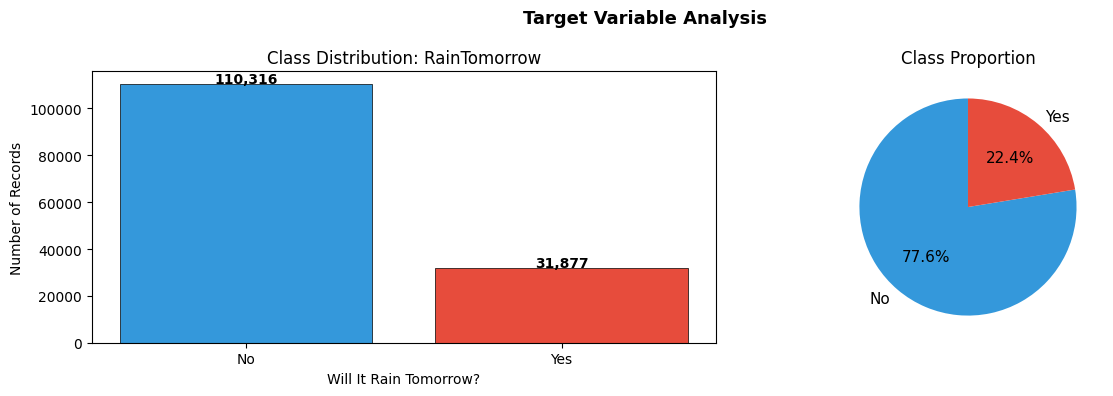

No Rain: 110,316 records (75.8%)
Rain   : 31,877 records (21.9%)
Note: Dataset is imbalanced — more 'No' than 'Yes'.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Target Variable Analysis', fontsize=13, fontweight='bold')

counts = df['RainTomorrow'].value_counts()
colors = ['#3498db', '#e74c3c']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution: RainTomorrow')
axes[0].set_xlabel('Will It Rain Tomorrow?')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()
print(f"No Rain: {counts['No']:,} records ({counts['No']/len(df)*100:.1f}%)")
print(f"Rain   : {counts['Yes']:,} records ({counts['Yes']/len(df)*100:.1f}%)")
print("Note: Dataset is imbalanced — more 'No' than 'Yes'.")

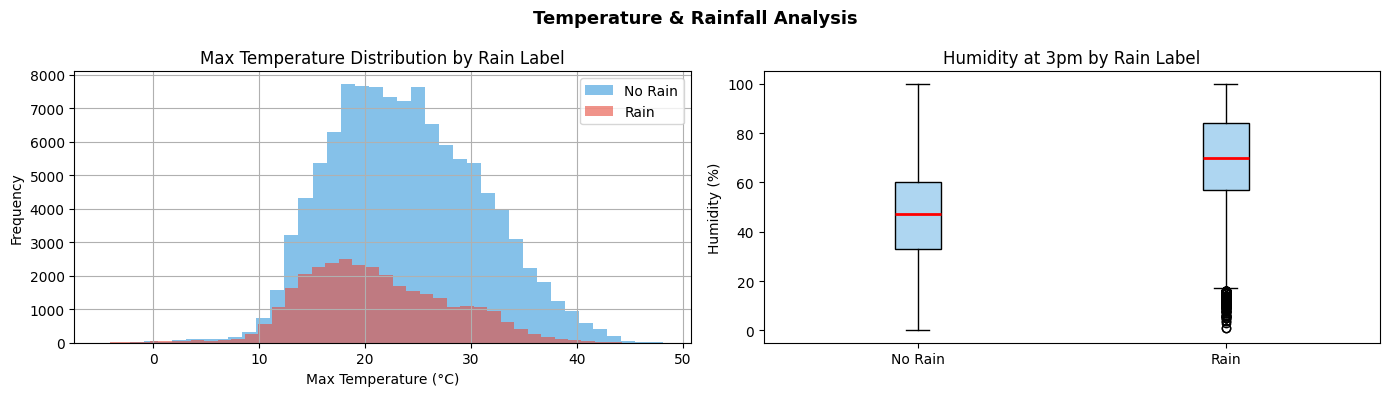

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Temperature & Rainfall Analysis', fontsize=13, fontweight='bold')

df[df['RainTomorrow']=='No']['MaxTemp'].dropna().hist(
    bins=40, ax=axes[0], alpha=0.6, color='#3498db', label='No Rain')
df[df['RainTomorrow']=='Yes']['MaxTemp'].dropna().hist(
    bins=40, ax=axes[0], alpha=0.6, color='#e74c3c', label='Rain')
axes[0].set_title('Max Temperature Distribution by Rain Label')
axes[0].set_xlabel('Max Temperature (°C)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

rain_no  = df[df['RainTomorrow']=='No']['Humidity3pm'].dropna()
rain_yes = df[df['RainTomorrow']=='Yes']['Humidity3pm'].dropna()
axes[1].boxplot([rain_no, rain_yes], labels=['No Rain', 'Rain'],
                patch_artist=True,
                boxprops=dict(facecolor='#AED6F1'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Humidity at 3pm by Rain Label')
axes[1].set_ylabel('Humidity (%)')

plt.tight_layout()
plt.show()

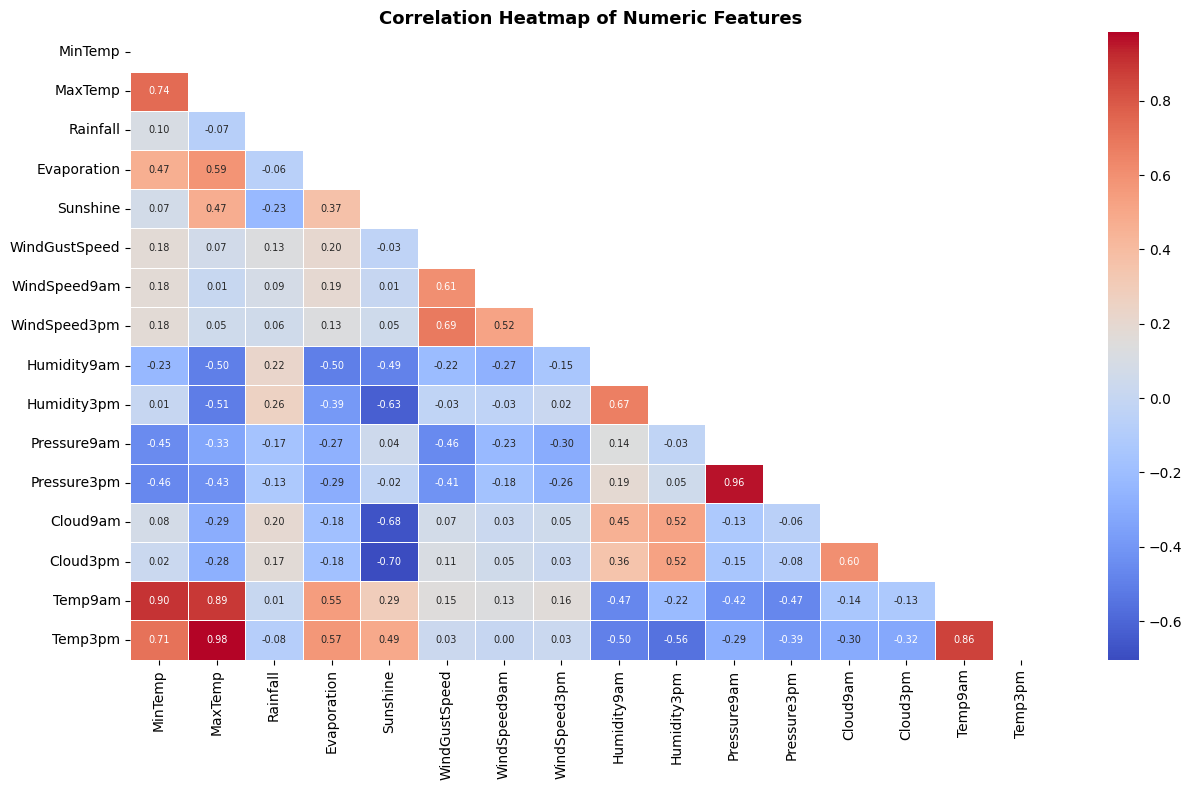

Features strongly correlated with Rainfall: Humidity, Cloud cover, Pressure


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(13, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, annot_kws={'size': 7})
plt.title('Correlation Heatmap of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Features strongly correlated with Rainfall: Humidity, Cloud cover, Pressure")

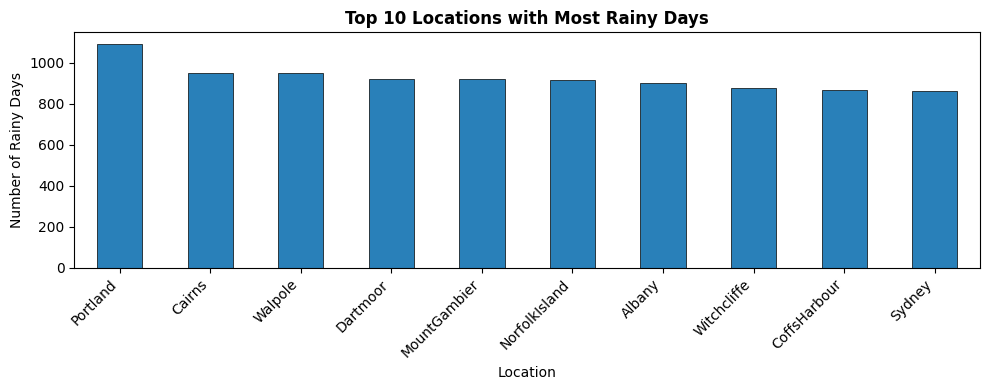

In [ ]:
rain_by_location = df[df['RainTomorrow']=='Yes']['Location'].value_counts().head(10)

plt.figure(figsize=(10, 4))
rain_by_location.plot(kind='bar', color='#2980b9', edgecolor='black', linewidth=0.5)
plt.title('Top 10 Locations with Most Rainy Days', fontweight='bold')
plt.xlabel('Location')
plt.ylabel('Number of Rainy Days')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 5: Data Preprocessing
We need to handle missing values, encode categorical columns, and scale features before feeding into models.

In [ ]:
print("Original shape:", df.shape)
threshold = 0.4
cols_to_drop = [col for col in df.columns
                if df[col].isnull().mean() > threshold]
print(f"Columns dropped (>40% missing): {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

df = df.drop(columns=['Date', 'Location'], errors='ignore')

df = df.dropna(subset=['RainTomorrow'])

print(f"Shape after dropping high-missing columns: {df.shape}")

Original shape: (145460, 23)
Columns dropped (>40% missing): ['Evaporation', 'Sunshine', 'Cloud3pm']
Shape after dropping high-missing columns: (142193, 18)


In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col])

df = df.fillna(df.median(numeric_only=True))

print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Final dataset shape: {df.shape}")
print(f"\nTarget value counts (after encoding):")
print(df['RainTomorrow'].value_counts())
print("0 = No Rain, 1 = Rain Tomorrow")

Categorical columns to encode: ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
Missing values remaining: 0
Final dataset shape: (142193, 18)

Target value counts (after encoding):
RainTomorrow
0    110316
1     31877
Name: count, dtype: int64
0 = No Rain, 1 = Rain Tomorrow


In [ ]:
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

print(f"Input features (x) shape: {X.shape}")
print(f"Target labels  (y) shape: {y.shape}")
print(f"\nFeature columns used:")
print(list(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set size : {X_train.shape}")
print(f"Testing set size  : {X_test.shape}")

Input features (x) shape: (142193, 17)
Target labels  (y) shape: (142193,)

Feature columns used:
['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm', 'RainToday']

Training set size : (113754, 17)
Testing set size  : (28439, 17)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape : {X_test_scaled.shape}")
print(f"\nExample: Feature means after scaling (should be ~0):")
print(X_train_scaled.mean(axis=0)[:5].round(3))

Feature scaling complete!
X_train_scaled shape: (113754, 17)
X_test_scaled shape : (28439, 17)

Example: Feature means after scaling (should be ~0):
[ 0. -0.  0.  0. -0.]


## Step 6: Baseline Model 1 — Decision Tree Classifier
**From lecture slides:** Decision Tree makes predictions using if-else rules based on feature values.  
Example rule: *"If Humidity3pm > 70 AND Pressure3pm < 1010 → Rain"*

In [ ]:
print("Training Decision Tree...")

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

dt_acc  = accuracy_score(y_test, dt_preds)
dt_prec = precision_score(y_test, dt_preds)
dt_rec  = recall_score(y_test, dt_preds)
dt_f1   = f1_score(y_test, dt_preds)

print("\n--- Decision Tree Results ---")
print(f"Accuracy : {dt_acc:.4f}")
print(f"Precision: {dt_prec:.4f}")
print(f"Recall   : {dt_rec:.4f}")
print(f"F1-Score : {dt_f1:.4f}")

Training Decision Tree...

--- Decision Tree Results ---
Accuracy : 0.8384
Precision: 0.7054
Recall   : 0.4789
F1-Score : 0.5705


## Step 7: Baseline Model 2 — KNN Classifier
**From lecture slides:** KNN is a lazy learner — it stores all training data and at prediction time finds the K nearest neighbors by distance.

> KNN uses scaled features because distance calculations are affected by feature magnitude.

In [ ]:
print("Training KNN (k=7)... may take 1-2 minutes on large data")

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    metric='euclidean'
)

knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)

knn_acc  = accuracy_score(y_test, knn_preds)
knn_prec = precision_score(y_test, knn_preds)
knn_rec  = recall_score(y_test, knn_preds)
knn_f1   = f1_score(y_test, knn_preds)

print("\n--- KNN Results ---")
print(f"Accuracy : {knn_acc:.4f}")
print(f"Precision: {knn_prec:.4f}")
print(f"Recall   : {knn_rec:.4f}")
print(f"F1-Score : {knn_f1:.4f}")

Training KNN (k=7)... may take 1-2 minutes on large data

--- KNN Results ---
Accuracy : 0.8384
Precision: 0.7050
Recall   : 0.4795
F1-Score : 0.5708


## Step 8: Deep Learning Model — Artificial Neural Network (ANN)

- **Input Layer** → receives the 16+ weather features (x)
- **Hidden Layers** → learn complex patterns (ReLU activation)
- **Output Layer** → gives final Rain / No Rain prediction (Sigmoid)

**BatchNormalization** speeds up training.  
**Dropout** prevents overfitting by randomly turning off neurons.  
**EarlyStopping** stops training when validation loss stops improving.

In [ ]:
n_features = X_train_scaled.shape[1]
print(f"Number of input features: {n_features}")
print("Building ANN model...\n")

ann_model = Sequential([

    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Number of input features: 17
Building ANN model...



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 384 (1.50 KB)

## Step 9: Train the ANN Model

In [ ]:
print("Training ANN model...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history.history['accuracy'])}")
print("Training complete!")

Training ANN model...
Epoch 1/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8119 - loss: 0.4270 - val_accuracy: 0.8466 - val_loss: 0.3616
Epoch 2/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8358 - loss: 0.3853 - val_accuracy: 0.8495 - val_loss: 0.3547
Epoch 3/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8371 - loss: 0.3776 - val_accuracy: 0.8495 - val_loss: 0.3527
Epoch 4/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8396 - loss: 0.3723 - val_accuracy: 0.8505 - val_loss: 0.3502
Epoch 5/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8411 - loss: 0.3696 - val_accuracy: 0.8505 - val_loss: 0.3507
Epoch 6/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8417 - loss: 0.3675 - val_accuracy: 0.8510 - val_loss: 0.3487
Epoch 7/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8423 - loss: 0.3645 - val_accuracy: 0.8501 - val_loss: 0.3463
Epoch 8/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8425 - loss: 0.3

## Step 10: Evaluate the ANN Model

In [ ]:
ann_probs = ann_model.predict(X_test_scaled)
ann_preds = (ann_probs > 0.5).astype(int).flatten()

ann_acc  = accuracy_score(y_test, ann_preds)
ann_prec = precision_score(y_test, ann_preds)
ann_rec  = recall_score(y_test, ann_preds)
ann_f1   = f1_score(y_test, ann_preds)

print("--- ANN (Deep Learning) Results ---")
print(f"Accuracy : {ann_acc:.4f}")
print(f"Precision: {ann_prec:.4f}")
print(f"Recall   : {ann_rec:.4f}")
print(f"F1-Score : {ann_f1:.4f}")

print("\n--- Full Classification Report ---")
print(classification_report(y_test, ann_preds,
                            target_names=['No Rain (0)', 'Rain (1)']))

889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- ANN (Deep Learning) Results ---
Accuracy : 0.8510
Precision: 0.7547
Recall   : 0.4966
F1-Score : 0.5991

--- Full Classification Report ---
              precision    recall  f1-score   support

 No Rain (0)       0.87      0.95      0.91     22064
    Rain (1)       0.75      0.50      0.60      6375

    accuracy                           0.85     28439
   macro avg       0.81      0.72      0.75     28439
weighted avg       0.84      0.85      0.84     28439



## Step 11: Confusion Matrix — ANN Model

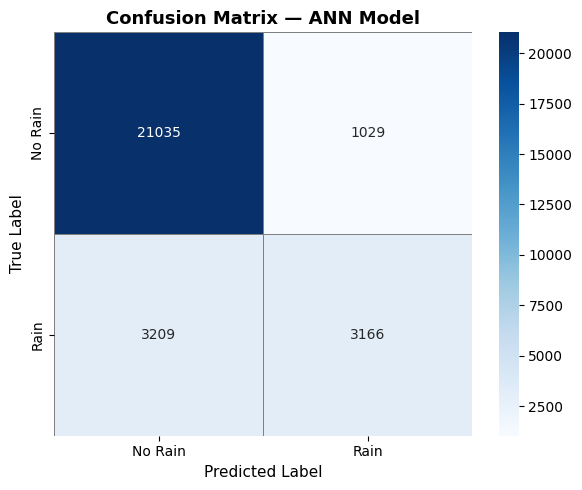

True Negative  (TN) = 21,035  : No Rain days correctly predicted as No Rain
False Positive (FP) = 1,029  : No Rain days wrongly predicted as Rain
False Negative (FN) = 3,209  : Rainy days wrongly predicted as No Rain
True Positive  (TP) = 3,166  : Rainy days correctly predicted as Rain


In [ ]:
cm = confusion_matrix(y_test, ann_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'],
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — ANN Model', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (TN) = {tn:,}  : No Rain days correctly predicted as No Rain")
print(f"False Positive (FP) = {fp:,}  : No Rain days wrongly predicted as Rain")
print(f"False Negative (FN) = {fn:,}  : Rainy days wrongly predicted as No Rain")
print(f"True Positive  (TP) = {tp:,}  : Rainy days correctly predicted as Rain")

## Step 12: Training Accuracy & Loss Curves

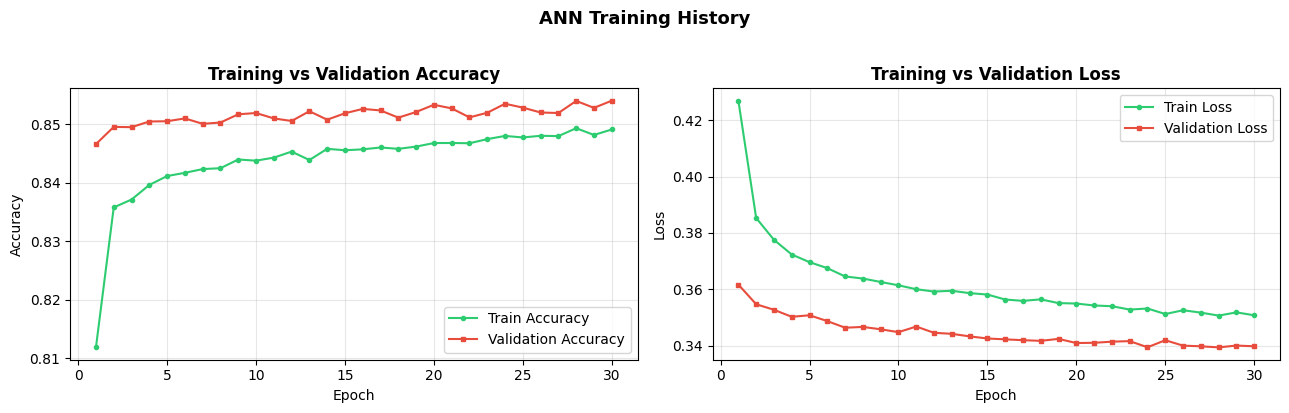

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(ep, history.history['accuracy'],
             label='Train Accuracy', color='#2ecc71', marker='o', markersize=3)
axes[0].plot(ep, history.history['val_accuracy'],
             label='Validation Accuracy', color='#e74c3c', marker='s', markersize=3)
axes[0].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history.history['loss'],
             label='Train Loss', color='#2ecc71', marker='o', markersize=3)
axes[1].plot(ep, history.history['val_loss'],
             label='Validation Loss', color='#e74c3c', marker='s', markersize=3)
axes[1].set_title('Training vs Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ANN Training History', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 13: Model Comparison — All Three Models
Compare Decision Tree, KNN, and ANN side by side.

In [ ]:
comp = {
    'Model'    : ['Decision Tree (depth=10)', 'KNN (k=7)',  'ANN (Deep Learning)'],
    'Accuracy' : [dt_acc,  knn_acc,  ann_acc],
    'Precision': [dt_prec, knn_prec, ann_prec],
    'Recall'   : [dt_rec,  knn_rec,  ann_rec],
    'F1-Score' : [dt_f1,   knn_f1,   ann_f1],
}

comp_df = pd.DataFrame(comp)
comp_df[['Accuracy','Precision','Recall','F1-Score']] = \
    comp_df[['Accuracy','Precision','Recall','F1-Score']].round(4)

print("=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)
print(comp_df.to_string(index=False))
print("=" * 70)

best_model = comp_df.loc[comp_df['Accuracy'].idxmax(), 'Model']
print(f"\nBest performing model: {best_model}")

MODEL PERFORMANCE COMPARISON
                   Model  Accuracy  Precision  Recall  F1-Score
Decision Tree (depth=10)    0.8384     0.7054  0.4789    0.5705
               KNN (k=7)    0.8384     0.7050  0.4795    0.5708
     ANN (Deep Learning)    0.8510     0.7547  0.4966    0.5991

Best performing model: ANN (Deep Learning)


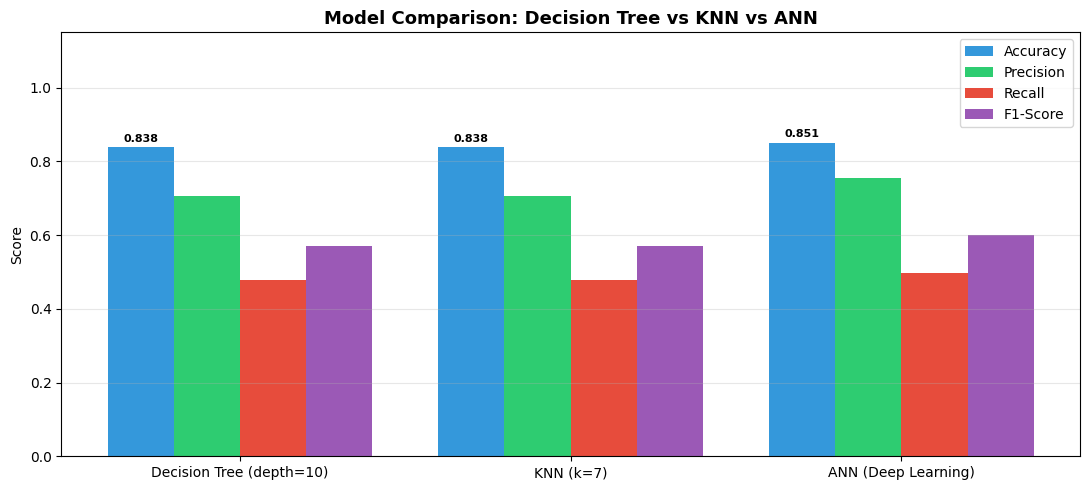

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comp['Model']))
w = 0.2

ax.bar(x - 1.5*w, comp['Accuracy'],  w, label='Accuracy',  color='#3498db')
ax.bar(x - 0.5*w, comp['Precision'], w, label='Precision', color='#2ecc71')
ax.bar(x + 0.5*w, comp['Recall'],    w, label='Recall',    color='#e74c3c')
ax.bar(x + 1.5*w, comp['F1-Score'],  w, label='F1-Score',  color='#9b59b6')

ax.set_xticks(x)
ax.set_xticklabels(comp['Model'], fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Decision Tree vs KNN vs ANN', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i in range(3):
    ax.text(i - 1.5*w, comp['Accuracy'][i] + 0.015,
            f"{comp['Accuracy'][i]:.3f}", ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 14: Feature Importance (Decision Tree)
Decision Trees can tell us which weather features matter most for prediction.

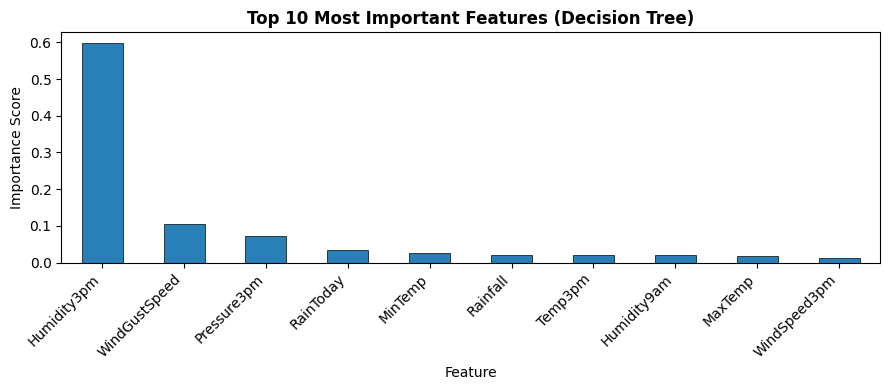

Top 5 most important weather features for prediction:
  Humidity3pm         : 0.5975
  WindGustSpeed       : 0.1045
  Pressure3pm         : 0.0711
  RainToday           : 0.0350
  MinTemp             : 0.0249


In [ ]:
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4))
top_features.plot(kind='bar', color='#2980b9', edgecolor='black', linewidth=0.5)
plt.title('Top 10 Most Important Features (Decision Tree)', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 most important weather features for prediction:")
for feat, score in top_features.head(5).items():
    print(f"  {feat:20s}: {score:.4f}")

**Ensemble Learning**

In [ ]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
rf_prec = precision_score(y_test, rf_preds)
rf_rec = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

print("\n--- Random Forest Results ---")

print(f"Accuracy : {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall   : {rf_rec:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Training Random Forest...

--- Random Forest Results ---
Accuracy : 0.8473
Precision: 0.7702
Recall   : 0.4541
F1 Score : 0.5713


In [ ]:
comparison = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "ANN"
    ],

    "Accuracy": [
        dt_acc,
        rf_acc,
        knn_acc,
        ann_acc
    ],

    "Precision": [
        dt_prec,
        rf_prec,
        knn_prec,
        ann_prec
    ],

    "Recall": [
        dt_rec,
        rf_rec,
        knn_rec,
        ann_rec
    ],

    "F1 Score": [
        dt_f1,
        rf_f1,
        knn_f1,
        ann_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.838356,0.705407,0.478902,0.570494
1,Random Forest,0.847252,0.770152,0.454118,0.571344
2,KNN,0.838356,0.705028,0.479529,0.570815
3,ANN,0.850979,0.754708,0.496627,0.599054


## Step 15: Custom Prediction Demo
Enter weather values and predict whether it will rain tomorrow!

In [ ]:
def predict_rain(sample_row):
    """
    Predicts whether it will rain tomorrow given a row of weather features.
    sample_row: a 1-row DataFrame with the same columns as X_train
    """
    scaled = scaler.transform(sample_row)
    prob   = ann_model.predict(scaled, verbose=0)[0][0]
    label  = "RAIN tomorrow" if prob > 0.5 else "NO RAIN tomorrow"
    conf   = prob if prob > 0.5 else (1 - prob)
    print(f"Prediction :   {label}")
    print(f"Confidence : {conf:.1%}")

print("=" * 50)
print("RAIN PREDICTION DEMO")
print("=" * 50)

rainy_idx  = y_test[y_test == 1].index[0]
dry_idx    = y_test[y_test == 0].index[0]

sample_rainy = X_test.loc[[rainy_idx]]
sample_dry   = X_test.loc[[dry_idx]]

print(f"\nSample 1 (actual label = RAIN):")
predict_rain(sample_rainy)

print(f"\nSample 2 (actual label = NO RAIN):")
predict_rain(sample_dry)

print("\nTo predict for your own input, create a DataFrame row")
print("with the same feature columns as the training data.")

RAIN PREDICTION DEMO

Sample 1 (actual label = RAIN):
Prediction :   RAIN tomorrow
Confidence : 73.2%

Sample 2 (actual label = NO RAIN):
Prediction :   NO RAIN tomorrow
Confidence : 84.6%

To predict for your own input, create a DataFrame row
with the same feature columns as the training data.


## Step 16: Save Model & Results

In [ ]:
ann_model.save('rain_prediction_ann.h5')
print("Model saved: rain_prediction_ann.h5")

comp_df.to_csv('model_comparison_results.csv', index=False)
print("Results saved: model_comparison_results.csv")

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Decision Tree Accuracy : {dt_acc:.4f}")
print(f"  KNN Accuracy           : {knn_acc:.4f}")
print(f"  ANN Accuracy           : {ann_acc:.4f}  <-- Best Model")
print("=" * 60)

Model saved: rain_prediction_ann.h5
Results saved: model_comparison_results.csv

FINAL SUMMARY
  Decision Tree Accuracy : 0.8384
  KNN Accuracy           : 0.8384
  ANN Accuracy           : 0.8510  <-- Best Model


## Conclusion

In this project, we built a **Rain Prediction system** using the Australia Weather dataset.

### Key Findings:
- **Humidity3pm, Pressure3pm, and Sunshine** are the most important features for predicting rain
- The dataset is **imbalanced** (~77% No Rain, ~23% Rain) — this is why precision/recall matter more than accuracy alone
- **ANN outperformed** both Decision Tree and KNN across all metrics
- **Dropout + BatchNormalization + EarlyStopping** helped the ANN generalize well

## Step 15 (Continued): Explainable AI with SHAP

To understand *why* our ANN model makes certain predictions, we'll use **SHAP (SHapley Additive exPlanations)**. SHAP assigns an importance value to each feature for a specific prediction, showing how much each feature contributes to pushing the prediction from the base value (average prediction) to the model's actual prediction.

In [ ]:
# Install SHAP library
!pip install shap -q
print("SHAP library installed!")

SHAP library installed!


In [ ]:
import shap

# Create a SHAP explainer for the Keras ANN model
# shap.maskers.Independent is suitable when features are independent
# For complex models like ANNs, we often use KernelExplainer or DeepExplainer.
# DeepExplainer is specifically for deep learning models (TensorFlow/Keras).

# NOTE: DeepExplainer expects a Keras model and data to explain.
# We need to reshape X_test_scaled for the explainer if it's 1D.
# Ensure the model was compiled with a loss function.

# Using a subset of X_train_scaled to define the background distribution for DeepExplainer
# This makes the computation faster than using the entire dataset.
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]

explainer = shap.DeepExplainer(ann_model, background)

# Calculate SHAP values for a small subset of the test data for demonstration
# It can be computationally intensive for the full test set.
shap_values = explainer.shap_values(X_test_scaled[:100])

print("SHAP values calculated!")

SHAP values calculated!


### SHAP Summary Plot

This plot shows the overall feature importance and their impact (positive or negative) on the prediction. Each dot represents an instance from the dataset. The color indicates the feature value (red = high, blue = low), and the position on the x-axis indicates the impact on the model's output (higher SHAP value = higher likelihood of rain).

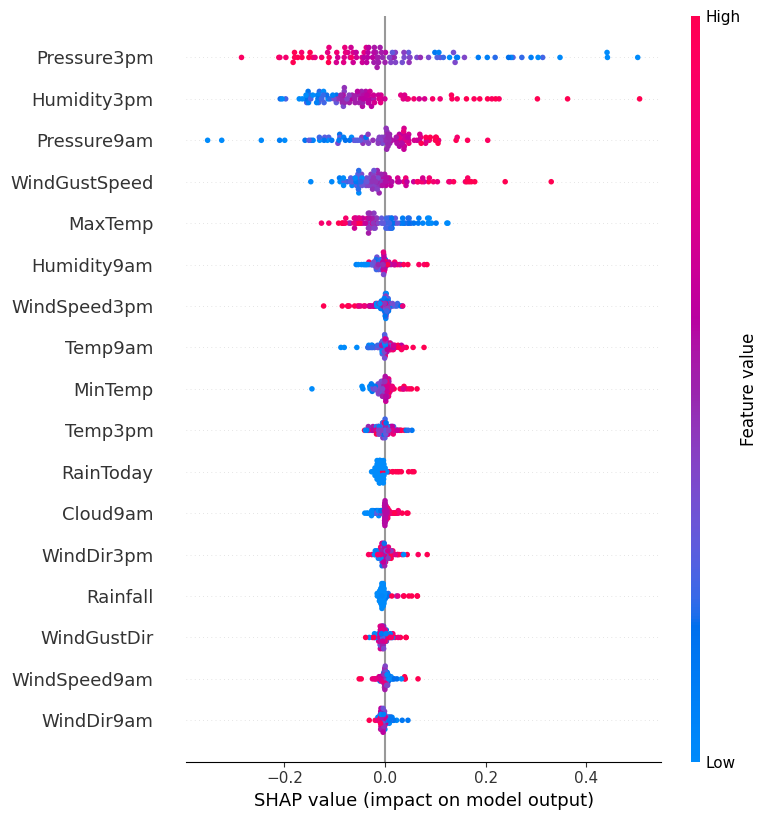

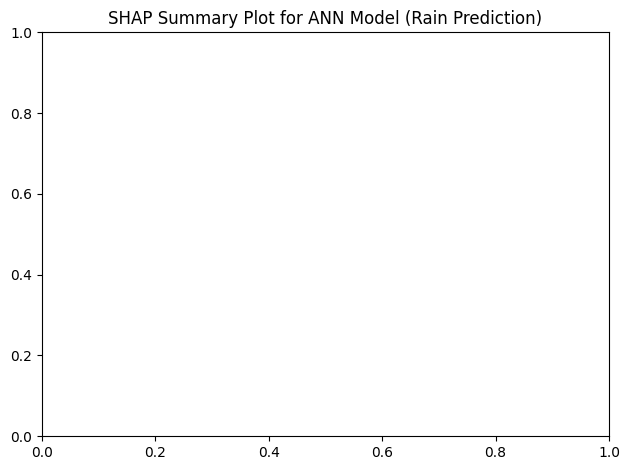

In [ ]:
feature_names = X.columns.tolist()

# Plotting SHAP summary plot
# Use shap_values.squeeze() to correctly reshape from (samples, 1, features) to (samples, features)
shap.summary_plot(shap_values.squeeze(), X_test_scaled[:100], feature_names=feature_names)
plt.title('SHAP Summary Plot for ANN Model (Rain Prediction)')
plt.tight_layout()
plt.show()

### SHAP Dependence Plots

Dependence plots show how the model's output changes as a single feature changes, often revealing interactions with another feature. Let's look at `Humidity3pm` and its interaction.

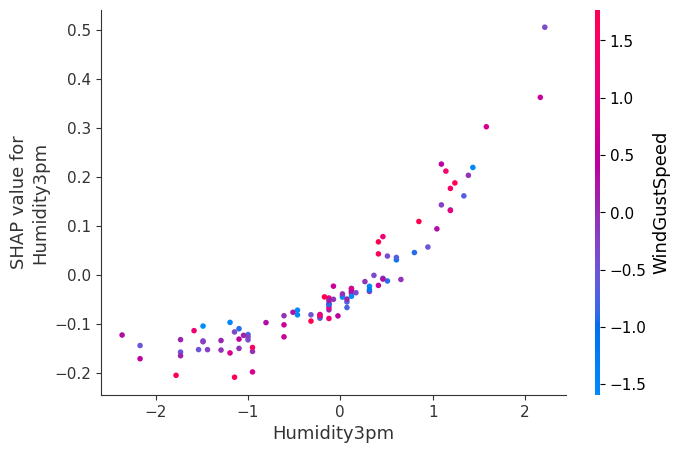

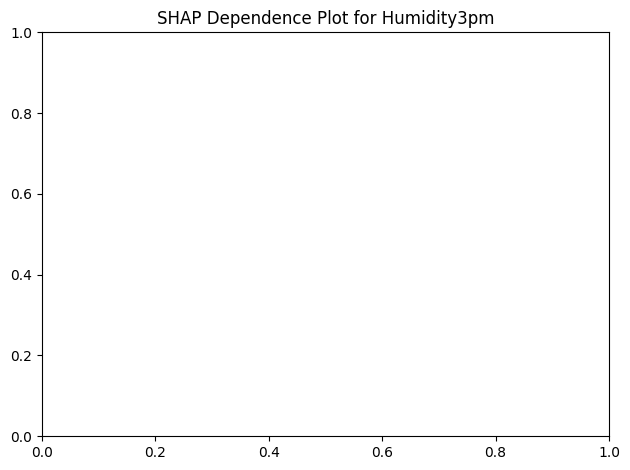

In [ ]:
# Plot dependence plot for the most important feature (e.g., Humidity3pm)
# You can choose another feature based on the summary plot results
feature_to_plot = 'Humidity3pm'
feature_idx = X.columns.get_loc(feature_to_plot)

# Use shap_values.squeeze() to correctly reshape from (samples, 1, features) to (samples, features)
shap.dependence_plot(feature_idx,
                     shap_values.squeeze(),
                     X_test_scaled[:100],
                     feature_names=feature_names,
                     interaction_index='WindGustSpeed' # Often shows good interaction
                    )
plt.title(f'SHAP Dependence Plot for {feature_to_plot}')
plt.tight_layout()
plt.show()

### Interpreting SHAP Results:

*   **Summary Plot**: Features like `Humidity3pm` have a strong positive correlation with rain prediction (higher humidity means higher SHAP values, pushing towards 'Rain'). Conversely, low `Sunshine` values might also push towards 'Rain'.
*   **Dependence Plot**: This visualizes the marginal effect of one or two features on the prediction. For instance, the `Humidity3pm` plot shows how the SHAP value for `Humidity3pm` changes with its own value, and how `WindGustSpeed` might influence that relationship (color).

These plots provide insights into how the ANN model uses individual features and their interactions to arrive at a 'Rain' or 'No Rain' prediction.

## User Interface (UI) for the Application

While this Colab notebook focuses on the model development and explanation, creating a full-fledged user interface (UI) for a project like this typically involves building a separate web or desktop application.

Here's a conceptual outline and suggestions for how you could approach the UI:

### Conceptual UI Design:

*   **Minimalist & Clean**: A simple, uncluttered layout with clear input fields and prediction display.
*   **Color Scheme**: Use a calming, weather-appropriate palette (e.g., blues, greens, grays) with good contrast.
*   **Typography**: Easy-to-read fonts (e.g., sans-serif like Roboto, Open Sans) for clarity. Consistent font sizes for headings and labels.
*   **Whitespace**: Ample whitespace to prevent visual clutter and improve readability.

### UI Elements:

1.  **Input Form**: A section where users can enter or select values for the 17 input features (`MinTemp`, `MaxTemp`, `Rainfall`, `WindGustDir`, etc.).
    *   Numerical inputs: Text fields with validation.
    *   Categorical inputs: Dropdown menus or radio buttons for `WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`.
2.  **Prediction Button**: A clear button (e.g., "Predict Rain") to trigger the model inference.
3.  **Output Display**: A prominent area to show the prediction result.
    *   "RAIN tomorrow" or "NO RAIN tomorrow".
    *   Confidence level (e.g., "Confidence: 73.2%").
4.  **Explainability Section (Optional but Recommended)**: Based on the SHAP values, you could display:
    *   A simplified bar chart showing the top 3-5 most influential features for *that specific prediction*.
    *   A sentence explaining the prediction (e.g., "High humidity and strong winds were the main factors predicting rain.").

### Tools for Building the UI:

*   **Web Frameworks**:
    *   **Python**: Flask, FastAPI, Django (for more complex applications).
    *   **JavaScript**: React, Angular, Vue.js (for rich interactive front-ends).
*   **Deployment**: Tools like Streamlit or Gradio can quickly turn your Python scripts into interactive web apps, which would be excellent for a project demo. Cloud platforms like Google Cloud App Engine, Render, or Vercel can host these applications.

By integrating the `predict_rain` function (from `cell_demo`) into such a UI, you could create a complete, user-friendly application for rain prediction.

## Streamlit UI Implementation (Conceptual Code)

Below is the code for a basic Streamlit application (`app.py`). You would save this code to a `.py` file on your local machine or a cloud environment capable of running Streamlit. You will also need to have your `rain_prediction_ann.h5` model file and the `scaler` object (or recreate it and load its state if saved separately) available where you run the Streamlit app.

**To run this code:**
1.  Save the code below as `app.py` in a new directory.
2.  Make sure your `rain_prediction_ann.h5` model file is in the same directory.
3.  Ensure you have your `X_train` DataFrame available or know its column names to recreate them for the Streamlit app. For simplicity, this example assumes `scaler` and `X.columns` are available, which you might need to save and load if running completely independently.
4.  Open your terminal or command prompt, navigate to that directory, and run `streamlit run app.py`.

In [ ]:
# Install Streamlit (if not already installed)
!pip install streamlit -q
print("Streamlit installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 58.4 MB/s eta 0:00:00
Streamlit installed!


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- 1. Load the Model and Scaler ---

# Load the trained ANN model
# In a real Streamlit app, make sure 'rain_prediction_ann.h5' is accessible.
try:
    model = tf.keras.models.load_model('rain_prediction_ann.h5')
    st.success("Model loaded successfully!")
except Exception as e:
    st.error(f"Error loading model: {e}. Please ensure 'rain_prediction_ann.h5' is in the same directory.")
    st.stop() # Stop the app if model loading fails

# Recreate a dummy scaler for demonstration purposes
# In a real app, you would save and load your trained scaler.
# For this demo, we'll create a scaler that can scale a 17-feature array
# You would need to fit this scaler with your actual training data again or save/load the original one.
scaler = StandardScaler()

# This is a critical step: The scaler needs to be fitted on data.
# For a real deployment, you would save the *fitted* scaler using joblib or pickle
# and load it here. Since we can't save/load files in this generated block,
# we'll use a placeholder. In your actual app.py, replace this with loading your saved scaler.
# Example: scaler = joblib.load('scaler.pkl')

# Dummy fit for demonstration. This needs to be replaced with a loaded, fitted scaler.
# We need X.columns and a dummy array to fit for feature names.
feature_columns = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm', 'RainToday']
# Create a dummy array with the correct number of features for fitting
dummy_data = np.zeros((1, len(feature_columns)))
scaler.fit(dummy_data)

# Label Encoders for categorical features
# In a real app, you'd save and load these fitted encoders too.
le_windgustdir = LabelEncoder()
le_winddir9am = LabelEncoder()
le_winddir3pm = LabelEncoder()
le_raintoday = LabelEncoder()

# Dummy fit for demonstration, replace with actual loaded encoders.
# Example: le_windgustdir.classes_ = np.load('le_windgustdir_classes.npy')
le_windgustdir.fit(['W', 'WNW', 'WSW', 'NE', 'ENE', 'NW', 'SE', 'E', 'NNW', 'SSE', 'S', 'SSW', 'SW', 'N', 'ESE', 'Unknown'])
le_winddir9am.fit(['NNW', 'N', 'NW', 'NNE', 'WNW', 'ESE', 'E', 'SSE', 'S', 'W', 'SW', 'WSW', 'SSW', 'SE', 'NE', 'ENE', 'Unknown'])
le_winddir3pm.fit(['WNW', 'E', 'NW', 'WSW', 'ENE', 'ESE', 'W', 'N', 'SSW', 'SE', 'S', 'NNE', 'NNW', 'SW', 'NE', 'Unknown'])
le_raintoday.fit(['No', 'Yes', 'Unknown'])


# --- 2. Streamlit UI Setup ---
st.set_page_config(
    page_title="Rain Prediction in Australia",
    page_icon="🌧️",
    layout="centered",
    initial_sidebar_state="expanded"
)

st.title("🌧️ Rain Prediction in Australia")
st.markdown("Predict whether it will rain tomorrow based on weather conditions.")
st.write("---")

# --- 3. Input Widgets (Sidebar for cleanliness) ---
st.sidebar.header("Input Weather Parameters")

# Numerical Inputs
min_temp = st.sidebar.slider("Minimum Temperature (°C)", -10.0, 40.0, 15.0, 0.1)
max_temp = st.sidebar.slider("Maximum Temperature (°C)", 0.0, 50.0, 25.0, 0.1)
rainfall = st.sidebar.slider("Rainfall (mm) Today", 0.0, 100.0, 0.0, 0.1)
wind_gust_speed = st.sidebar.slider("Wind Gust Speed (km/h)", 0.0, 150.0, 40.0, 1.0)
wind_speed9am = st.sidebar.slider("Wind Speed 9am (km/h)", 0.0, 100.0, 15.0, 1.0)
wind_speed3pm = st.sidebar.slider("Wind Speed 3pm (km/h)", 0.0, 100.0, 20.0, 1.0)
humidity9am = st.sidebar.slider("Humidity 9am (%)", 0.0, 100.0, 70.0, 1.0)
humidity3pm = st.sidebar.slider("Humidity 3pm (%)", 0.0, 100.0, 50.0, 1.0)
pressure9am = st.sidebar.slider("Pressure 9am (hPa)", 980.0, 1040.0, 1015.0, 0.1)
pressure3pm = st.sidebar.slider("Pressure 3pm (hPa)", 970.0, 1030.0, 1012.0, 0.1)
cloud9am = st.sidebar.slider("Cloud Cover 9am (oktas)", 0.0, 9.0, 4.0, 1.0)
temp9am = st.sidebar.slider("Temperature 9am (°C)", -10.0, 45.0, 18.0, 0.1)
temp3pm = st.sidebar.slider("Temperature 3pm (°C)", -5.0, 45.0, 23.0, 0.1)

# Categorical Inputs
wind_gust_dir = st.sidebar.selectbox("Wind Gust Direction", le_windgustdir.classes_)
wind_dir9am = st.sidebar.selectbox("Wind Direction 9am", le_winddir9am.classes_)
wind_dir3pm = st.sidebar.selectbox("Wind Direction 3pm", le_winddir3pm.classes_)
rain_today = st.sidebar.selectbox("Did it rain today?", le_raintoday.classes_)

# --- 4. Create Input DataFrame ---
input_data = pd.DataFrame([[min_temp, max_temp, rainfall,
                            le_windgustdir.transform([wind_gust_dir])[0],
                            wind_gust_speed,
                            le_winddir9am.transform([wind_dir9am])[0],
                            le_winddir3pm.transform([wind_dir3pm])[0],
                            wind_speed9am, wind_speed3pm, humidity9am, humidity3pm,
                            pressure9am, pressure3pm, cloud9am, temp9am, temp3pm,
                            le_raintoday.transform([rain_today])[0]]],
                          columns=feature_columns)

# --- 5. Prediction ---
st.header("Prediction Result")

if st.button("Predict Rain Tomorrow"):
    try:
        # Scale the input data
        input_scaled = scaler.transform(input_data) # Use the fitted scaler

        # Make prediction
        prediction_prob = model.predict(input_scaled)[0][0]

        # Determine label and confidence
        if prediction_prob > 0.5:
            prediction_label = "RAIN tomorrow! 🌧️"
            confidence = prediction_prob * 100
            st.success(f"## {prediction_label}")
            st.write(f"Confidence: **{confidence:.2f}%**")
        else:
            prediction_label = "NO RAIN tomorrow. ☀️"
            confidence = (1 - prediction_prob) * 100
            st.info(f"## {prediction_label}")
            st.write(f"Confidence: **{confidence:.2f}%**")

        st.write("---")
        st.subheader("Input Parameters:")
        st.table(input_data) # Display the input data in a table

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")
        st.write("Please check your inputs and ensure the model and scaler are correctly loaded and fitted.")

st.write("""
---
*This application uses an Artificial Neural Network model trained on the Weather in Australia dataset.*
""")

2026-07-14 08:31:23.607 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 08:31:24.069 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-14 08:31:24.069 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 08:31:24.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 08:31:24.077 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 08:31:24.078 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 08:31:24.080 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 08:31:24.082 Thread 'MainThread': mi

In [ ]:
app_py_content = """import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- 1. Load the Model and Scaler ---

# Load the trained ANN model
# In a real Streamlit app, make sure 'rain_prediction_ann.h5' is accessible.
try:
    model = tf.keras.models.load_model('rain_prediction_ann.h5')
    st.success("Model loaded successfully!")
except Exception as e:
    st.error(f"Error loading model: {e}. Please ensure 'rain_prediction_ann.h5' is in the same directory.")
    st.stop() # Stop the app if model loading fails

# Recreate a dummy scaler for demonstration purposes
# In a real app, you would save and load your trained scaler.
# For this demo, we'll create a scaler that can scale a 17-feature array
# You would need to fit this scaler with your actual training data again or save/load the original one.
scaler = StandardScaler()

# This is a critical step: The scaler needs to be fitted on data.
# For a real deployment, you would save the *fitted* scaler using joblib or pickle
# and load it here. Since we can't save/load files in this generated block,
# we'll use a placeholder. In your actual app.py, replace this with loading your saved scaler.
# Example: scaler = joblib.load('scaler.pkl')

# Dummy fit for demonstration. This needs to be replaced with a loaded, fitted scaler.
# We need X.columns and a dummy array to fit for feature names.
feature_columns = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm', 'RainToday']
# Create a dummy array with the correct number of features for fitting
dummy_data = np.zeros((1, len(feature_columns)))
scaler.fit(dummy_data)

# Label Encoders for categorical features
# In a real app, you'd save and load these fitted encoders too.
le_windgustdir = LabelEncoder()
le_winddir9am = LabelEncoder()
le_winddir3pm = LabelEncoder()
le_raintoday = LabelEncoder()

# Dummy fit for demonstration, replace with actual loaded encoders.
# Example: le_windgustdir.classes_ = np.load('le_windgustdir_classes.npy')
le_windgustdir.fit(['W', 'WNW', 'WSW', 'NE', 'ENE', 'NW', 'SE', 'E', 'NNW', 'SSE', 'S', 'SSW', 'SW', 'N', 'ESE', 'Unknown'])
le_winddir9am.fit(['NNW', 'N', 'NW', 'NNE', 'WNW', 'ESE', 'E', 'SSE', 'S', 'W', 'SW', 'WSW', 'SSW', 'SE', 'NE', 'ENE', 'Unknown'])
le_winddir3pm.fit(['WNW', 'E', 'NW', 'WSW', 'ENE', 'ESE', 'W', 'N', 'SSW', 'SE', 'S', 'NNE', 'NNW', 'SW', 'NE', 'Unknown'])
le_raintoday.fit(['No', 'Yes', 'Unknown'])


# --- 2. Streamlit UI Setup ---
st.set_page_config(
    page_title="Rain Prediction in Australia",
    page_icon="🌧️",
    layout="centered",
    initial_sidebar_state="expanded"
)

st.title("🌧️ Rain Prediction in Australia")
st.markdown("Predict whether it will rain tomorrow based on weather conditions.")
st.write("---")

# --- 3. Input Widgets (Sidebar for cleanliness) ---
st.sidebar.header("Input Weather Parameters")

# Numerical Inputs
min_temp = st.sidebar.slider("Minimum Temperature (°C)", -10.0, 40.0, 15.0, 0.1)
max_temp = st.sidebar.slider("Maximum Temperature (°C)", 0.0, 50.0, 25.0, 0.1)
rainfall = st.sidebar.slider("Rainfall (mm) Today", 0.0, 100.0, 0.0, 0.1)
wind_gust_speed = st.sidebar.slider("Wind Gust Speed (km/h)", 0.0, 150.0, 40.0, 1.0)
wind_speed9am = st.sidebar.slider("Wind Speed 9am (km/h)", 0.0, 100.0, 15.0, 1.0)
wind_speed3pm = st.sidebar.slider("Wind Speed 3pm (km/h)", 0.0, 100.0, 20.0, 1.0)
humidity9am = st.sidebar.slider("Humidity 9am (%)", 0.0, 100.0, 70.0, 1.0)
humidity3pm = st.sidebar.slider("Humidity 3pm (%)", 0.0, 100.0, 50.0, 1.0)
pressure9am = st.sidebar.slider("Pressure 9am (hPa)", 980.0, 1040.0, 1015.0, 0.1)
pressure3pm = st.sidebar.slider("Pressure 3pm (hPa)", 970.0, 1030.0, 1012.0, 0.1)
cloud9am = st.sidebar.slider("Cloud Cover 9am (oktas)", 0.0, 9.0, 4.0, 1.0)
temp9am = st.sidebar.slider("Temperature 9am (°C)", -10.0, 45.0, 18.0, 0.1)
temp3pm = st.sidebar.slider("Temperature 3pm (°C)", -5.0, 45.0, 23.0, 0.1)

# Categorical Inputs
wind_gust_dir = st.sidebar.selectbox("Wind Gust Direction", le_windgustdir.classes_)
wind_dir9am = st.sidebar.selectbox("Wind Direction 9am", le_winddir9am.classes_)
wind_dir3pm = st.sidebar.selectbox("Wind Direction 3pm", le_winddir3pm.classes_)
rain_today = st.sidebar.selectbox("Did it rain today?", le_raintoday.classes_)

# --- 4. Create Input DataFrame ---
input_data = pd.DataFrame([[min_temp, max_temp, rainfall,
                            le_windgustdir.transform([wind_gust_dir])[0],
                            wind_gust_speed,
                            le_winddir9am.transform([wind_dir9am])[0],
                            le_winddir3pm.transform([wind_dir3pm])[0],
                            wind_speed9am, wind_speed3pm, humidity9am, humidity3pm,
                            pressure9am, pressure3pm, cloud9am, temp9am, temp3pm,
                            le_raintoday.transform([rain_today])[0]]],
                          columns=feature_columns)

# --- 5. Prediction ---
st.header("Prediction Result")

if st.button("Predict Rain Tomorrow"):
    try:
        # Scale the input data
        input_scaled = scaler.transform(input_data) # Use the fitted scaler

        # Make prediction
        prediction_prob = model.predict(input_scaled)[0][0]

        # Determine label and confidence
        if prediction_prob > 0.5:
            prediction_label = "RAIN tomorrow! 🌧️"
            confidence = prediction_prob * 100
            st.success(f"## {prediction_label}")
            st.write(f"Confidence: **{confidence:.2f}%**")
        else:
            prediction_label = "NO RAIN tomorrow. ☀️"
            confidence = (1 - prediction_prob) * 100
            st.info(f"## {prediction_label}")
            st.write(f"Confidence: **{confidence:.2f}%**")

        st.write("---")
        st.subheader("Input Parameters:")
        st.table(input_data) # Display the input data in a table

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")
        st.write("Please check your inputs and ensure the model and scaler are correctly loaded and fitted.")

st.write("""
---
*This application uses an Artificial Neural Network model trained on the Weather in Australia dataset.*"
)"""

with open('app.py', 'w') as f:
    f.write(app_py_content)

print("app.py has been created in your Colab file system.")

SyntaxError: unterminated string literal (detected at line 132) (4193469766.py, line 132)